In [8]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/hilalyldrm/healthdata/healthcare-dataset-stroke-data.csv')

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [9]:
df.shape


(5110, 12)

In [10]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [11]:
df['bmi'].median()

28.1

In [12]:
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

In [13]:
df.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [14]:
df['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [15]:
df['stroke'].value_counts(normalize=True) * 100

stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64

In [16]:
df['gender'].value_counts()

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

In [17]:
df['ever_married'].value_counts()

ever_married
Yes    3353
No     1757
Name: count, dtype: int64

In [18]:
df['work_type'].value_counts()

work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

In [19]:
df['Residence_type'].value_counts()

Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

In [20]:
df['smoking_status'].value_counts()

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64

In [21]:
df = df[df['gender'] != 'Other']

In [22]:
df.shape

(5109, 12)

In [23]:
df = df.drop('id', axis=1)

In [24]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grafiklerin düzgün görünmesi için stil ayarı
sns.set_theme(style="whitegrid")

stroke
0    4861
1     249
Name: count, dtype: int64
stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


/tmp/ipykernel_58/2650010549.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='stroke', data=df, palette='Set2')


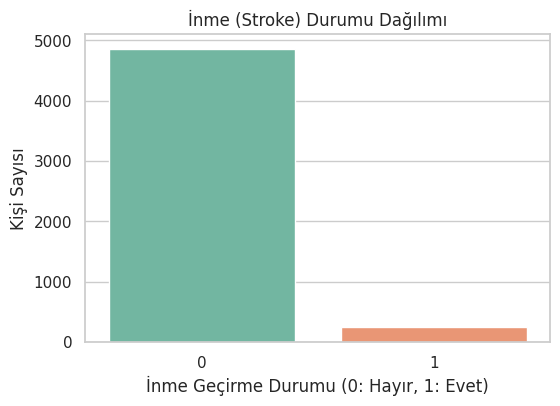

In [51]:
# 1. Hedef değişkenin sayılması ve görselleştirilmesi
print(df['stroke'].value_counts())
print(df['stroke'].value_counts(normalize=True) * 100) 

plt.figure(figsize=(6, 4))
sns.countplot(x='stroke', data=df, palette='Set2')
plt.title('İnme (Stroke) Durumu Dağılımı')
plt.xlabel('İnme Geçirme Durumu (0: Hayır, 1: Evet)')
plt.ylabel('Kişi Sayısı')
plt.show()

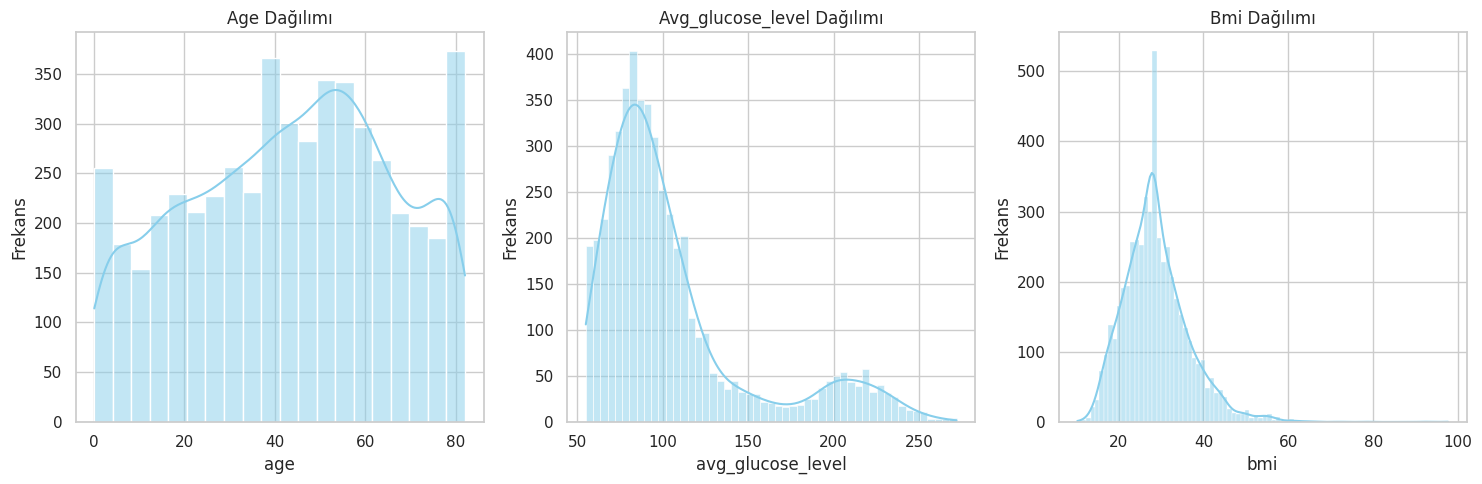

--- Sayısal Değişkenlerin İstatistiki Özeti ---
               age  avg_glucose_level          bmi
count  5109.000000        5109.000000  5109.000000
mean     43.229986         106.140399    28.863300
std      22.613575          45.285004     7.699785
min       0.080000          55.120000    10.300000
25%      25.000000          77.240000    23.800000
50%      45.000000          91.880000    28.100000
75%      61.000000         114.090000    32.800000
max      82.000000         271.740000    97.600000


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sayısal kolonların listesi
numerical_cols = ['age', 'avg_glucose_level', 'bmi']

# Grafik alanını oluşturma
plt.figure(figsize=(15, 5))

# Her bir sayısal kolon için histogram çizdirme
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 3, i)
    # hue ve legend ekleyerek gelecekteki uyarıların önüne geçiyoruz
    sns.histplot(data=df, x=col, kde=True, color='skyblue')
    plt.title(f'{col.capitalize()} Dağılımı')
    plt.xlabel(col)
    plt.ylabel('Frekans')

plt.tight_layout()
plt.show()

# Sayısal verilerin temel istatistik özetleri
print("--- Sayısal Değişkenlerin İstatistiki Özeti ---")
print(df[numerical_cols].describe())

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Veri setini yükle
df = pd.read_csv('/kaggle/input/datasets/hilalyldrm/healthdata/healthcare-dataset-stroke-data.csv')

Text(0, 0.5, 'Yaş')

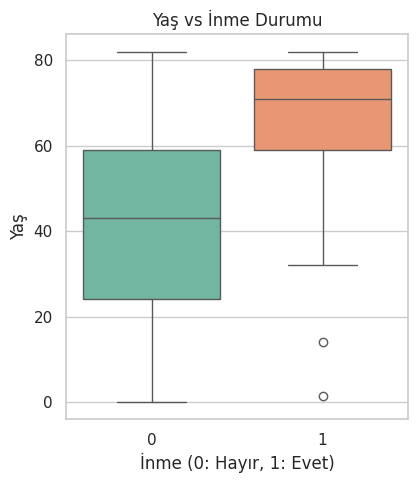

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sayısal değişkenlerin İnme (Stroke) durumuna göre Boxplot analizi
plt.figure(figsize=(15, 5))

# 1. Yaş vs İnme
plt.subplot(1, 3, 1)
sns.boxplot(x='stroke', y='age', data=df, hue='stroke', palette='Set2', legend=False)
plt.title('Yaş vs İnme Durumu')
plt.xlabel('İnme (0: Hayır, 1: Evet)')
plt.ylabel('Yaş')



Text(0, 0.5, 'Ortalama Glikoz Seviyesi')

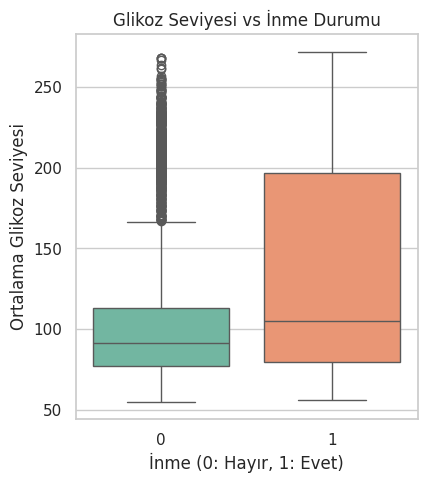

In [53]:

plt.figure(figsize=(15, 5))


# 2. Glikoz Seviyesi vs İnme
plt.subplot(1, 3, 2)
sns.boxplot(x='stroke', y='avg_glucose_level', data=df, hue='stroke', palette='Set2', legend=False)
plt.title('Glikoz Seviyesi vs İnme Durumu')
plt.xlabel('İnme (0: Hayır, 1: Evet)')
plt.ylabel('Ortalama Glikoz Seviyesi')



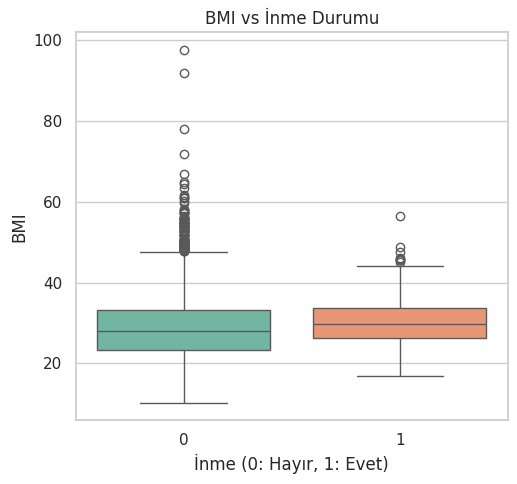

In [54]:

plt.figure(figsize=(15, 5))

# 3. BMI vs İnme
plt.subplot(1, 3, 3)
sns.boxplot(x='stroke', y='bmi', data=df, hue='stroke', palette='Set2', legend=False)
plt.title('BMI vs İnme Durumu')
plt.xlabel('İnme (0: Hayır, 1: Evet)')
plt.ylabel('BMI')

plt.tight_layout()
plt.show()

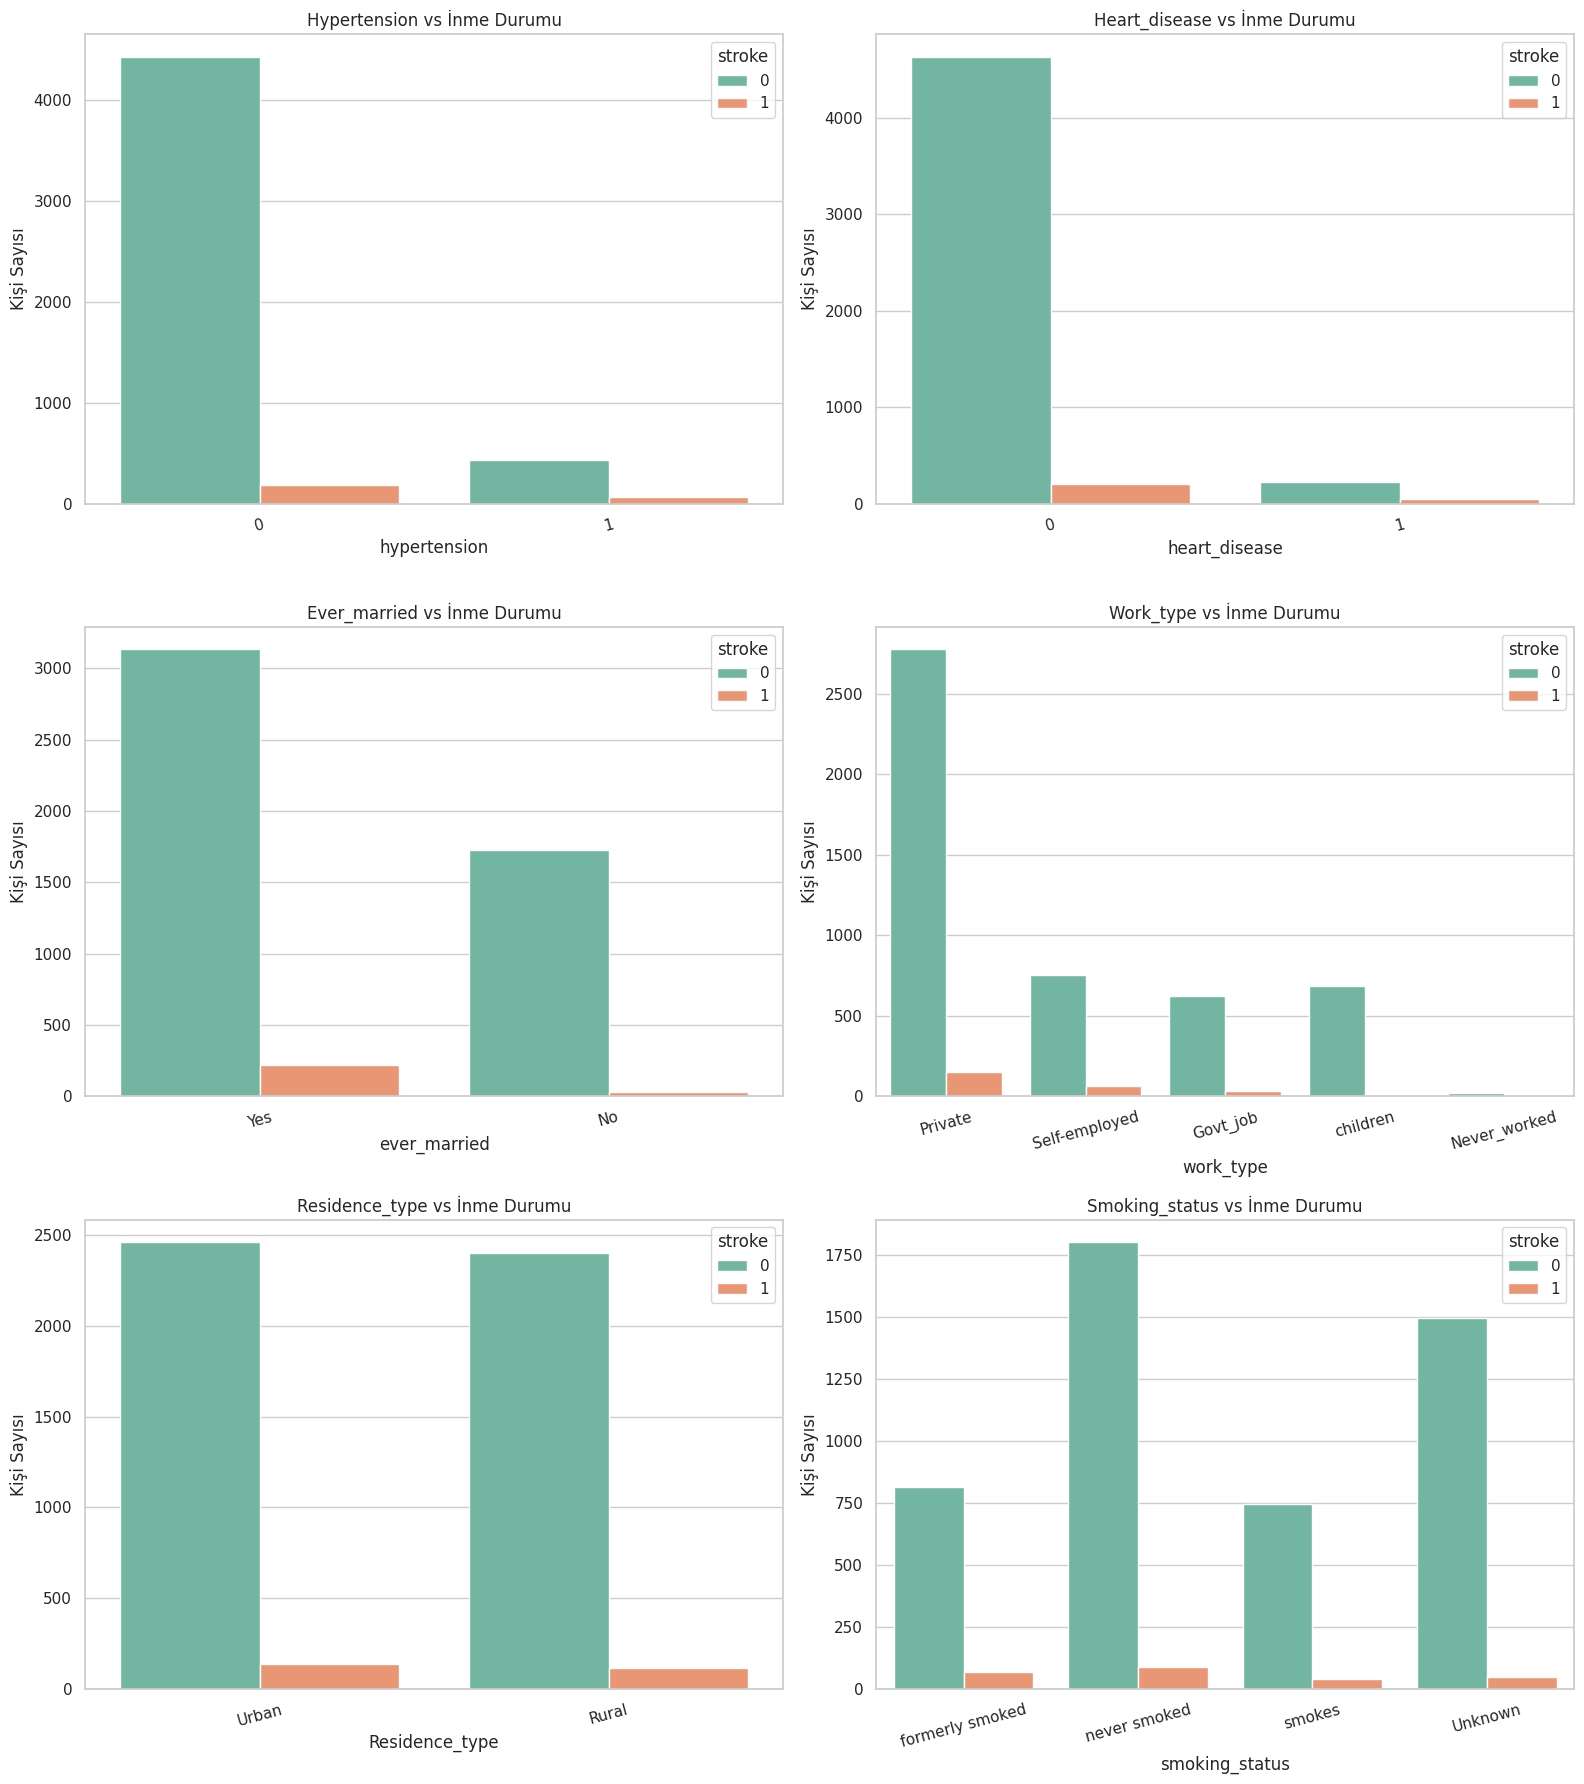

In [55]:
# Kategorik değişkenleri listeliyoruz
categorical_cols = ['hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

# Grafik alanını hazırlıyoruz 
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
   
    sns.countplot(x=col, hue='stroke', data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col.capitalize()} vs İnme Durumu')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Kişi Sayısı')
    
   
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

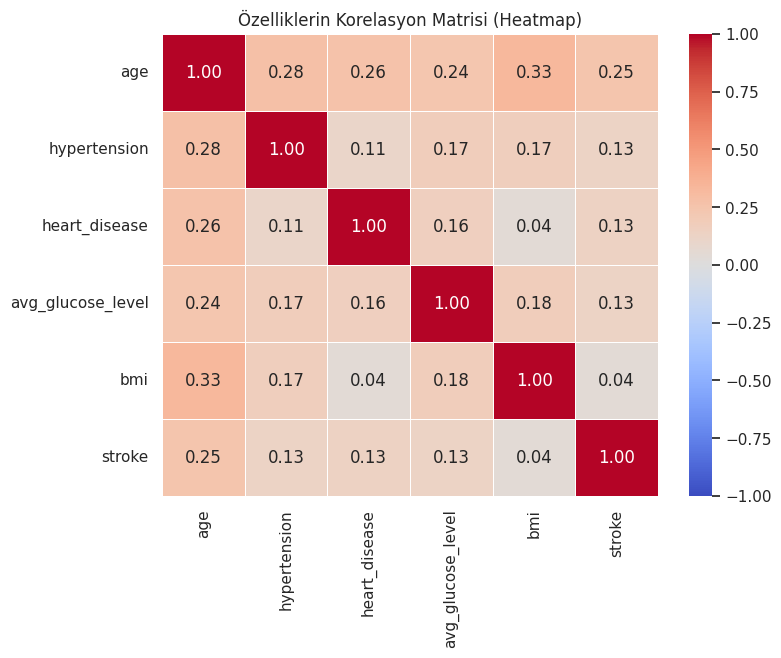

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns 

corr_cols = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']

# Korelasyon matrisini hesaplama
corr_matrix = df[corr_cols].corr()

# Isı haritasını çizdirme
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Özelliklerin Korelasyon Matrisi (Heatmap)')
plt.show()

In [57]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. KATEGORİK DEĞİŞKENLERİ DÖNÜŞTÜRME

df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)

# 2. BAĞIMSIZ VE BAĞIMLI DEĞİŞKENLERİ AYIRMA
X = df_encoded.drop(columns=['stroke'])
y = df_encoded['stroke']

# 3. VERİYİ EĞİTİM VE TEST OLARAK BÖLME
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. SAYISAL VERİLERİ ÖLÇEKLENDİRME
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. GELİŞMİŞ RANDOM FOREST MODELİ

model = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    class_weight='balanced_subsample',
    max_depth=10 
)
model.fit(X_train_scaled, y_train)

# 6. TAHMİN VE RAPORLAMA
y_pred = model.predict(X_test_scaled)

print("--- YENİ MODEL BAŞARI RAPORU ---")
print(classification_report(y_test, y_pred, zero_division=0))

print("--- HATA MATRİSİ (Confusion Matrix) ---")
print(confusion_matrix(y_test, y_pred))

--- YENİ MODEL BAŞARI RAPORU ---
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       972
           1       0.27      0.16      0.20        50

    accuracy                           0.94      1022
   macro avg       0.61      0.57      0.58      1022
weighted avg       0.92      0.94      0.93      1022

--- HATA MATRİSİ (Confusion Matrix) ---
[[950  22]
 [ 42   8]]


In [58]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. MEVCUT DF'İN SON HALİNİ KORUMA VE TEMİZLEME
df_ml = df.dropna().copy()

if 'id' in df_ml.columns:
    df_ml = df_ml.drop(columns=['id'])

# 2. KATEGORİK DEĞİŞKENLERİ DÖNÜŞTÜRME (One-Hot Encoding)

df_encoded = pd.get_dummies(df_ml, drop_first=True, dtype=int)

# 3. HEDEF VE ÖZELLİK AYRIMI
X = df_encoded.drop(columns=['stroke'])
y = df_encoded['stroke']

# 4. TRAIN - TEST AYRIMI 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. ÖLÇEKLENDİRME 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. SMOTE İLE VERİYİ DENGEME 

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"Orijinal Eğitim Setindeki İnme Vakası (1) Sayısı: {sum(y_train == 1)}")
print(f"SMOTE Sonrası Eğitim Setindeki İnme Vakası (1) Sayısı: {sum(y_train_resampled == 1)}\n")

# 7. MODELİ DENGELENMİŞ VERİYLE EĞİTME
smote_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
smote_model.fit(X_train_resampled, y_train_resampled)

# 8. TAHMİN VE RAPORLAMA 
y_pred_smote = smote_model.predict(X_test_scaled)

print("--- SMOTE SONRASI MODEL BAŞARI RAPORU ---")
print(classification_report(y_test, y_pred_smote, zero_division=0))

print("--- SMOTE SONRASI HATA MATRİSİ ---")
print(confusion_matrix(y_test, y_pred_smote))

Orijinal Eğitim Setindeki İnme Vakası (1) Sayısı: 167
SMOTE Sonrası Eğitim Setindeki İnme Vakası (1) Sayısı: 3760

--- SMOTE SONRASI MODEL BAŞARI RAPORU ---
              precision    recall  f1-score   support

           0       0.97      0.88      0.92       940
           1       0.13      0.40      0.20        42

    accuracy                           0.86       982
   macro avg       0.55      0.64      0.56       982
weighted avg       0.93      0.86      0.89       982

--- SMOTE SONRASI HATA MATRİSİ ---
[[830 110]
 [ 25  17]]


SİSTEM: En İyi Random Forest Parametreleri Aranıyor...

[BAŞARILI] Bulunan En İyi Model Ayarları: {'criterion': 'entropy', 'max_depth': 12, 'min_samples_split': 2, 'n_estimators': 150}

HYPERPARAMETER TUNING (GRID SEARCH) SONRASI RAPOR
              precision    recall  f1-score   support

           0       0.96      0.91      0.94       940
           1       0.08      0.17      0.11        42

    accuracy                           0.88       982
   macro avg       0.52      0.54      0.52       982
weighted avg       0.92      0.88      0.90       982

YENİ HATA MATRİSİ (CONFUSION MATRIX) RAKAMLARI
[[860  80]
 [ 35   7]]


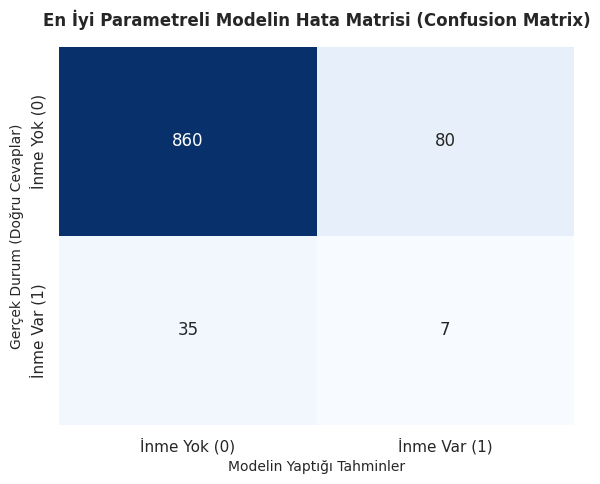

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


# ADIM 1: HİPERPARAMETRE SEÇENEKLERİNİ BELİRLEME
param_grid = {
    'n_estimators': [50, 100, 150],       
    'max_depth': [5, 8, 12],             
    'min_samples_split': [2, 5],          
    'criterion': ['gini', 'entropy']    
}


# ADIM 2: GRID SEARCH SETUP 

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='recall', 
    cv=3,             
    n_jobs=-1         
)


# ADIM 3: EN İYİ MODELİ BULMAK İÇİN EĞİTİM


print("SİSTEM: En İyi Random Forest Parametreleri Aranıyor...")

grid_search.fit(X_train_resampled, y_train_resampled)

print(f"\n[BAŞARILI] Bulunan En İyi Model Ayarları: {grid_search.best_params_}\n")


# ADIM 4: EN İYİ MODELİ SEÇME VE TEST VERİSİYLE TAHMİN 

best_model = grid_search.best_estimator_
y_pred_grid = best_model.predict(X_test_scaled)


# ADIM 5: SONUÇLARI METİNSEL OLARAK RAPORLAMA 
print("HYPERPARAMETER TUNING (GRID SEARCH) SONRASI RAPOR")
print(classification_report(y_test, y_pred_grid, zero_division=0))


# ADIM 6: HATA MATRİSİNİ GÖRSEL OLARAK ÇİZDİRME 

print("YENİ HATA MATRİSİ (CONFUSION MATRIX) RAKAMLARI")
cm = confusion_matrix(y_test, y_pred_grid)
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['İnme Yok (0)', 'İnme Var (1)'],
            yticklabels=['İnme Yok (0)', 'İnme Var (1)'])
plt.title('En İyi Parametreli Modelin Hata Matrisi (Confusion Matrix)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Modelin Yaptığı Tahminler', fontsize=10)
plt.ylabel('Gerçek Durum (Doğru Cevaplar)', fontsize=10)
plt.tight_layout()
plt.show()

FİNAL MODEL BAŞARI RAPORU
              precision    recall  f1-score   support

           0       0.97      0.88      0.92       940
           1       0.13      0.40      0.20        42

    accuracy                           0.86       982
   macro avg       0.55      0.64      0.56       982
weighted avg       0.93      0.86      0.89       982



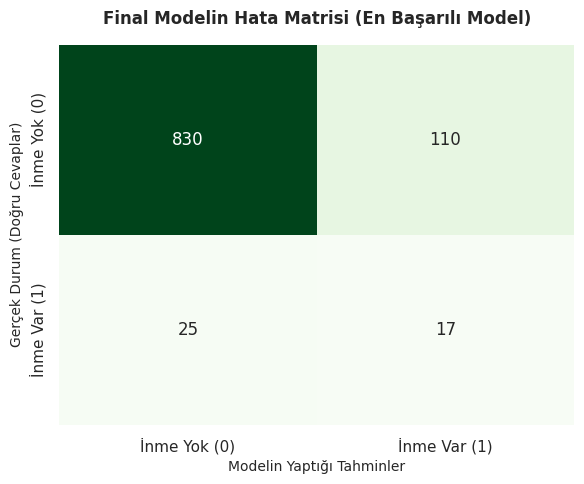

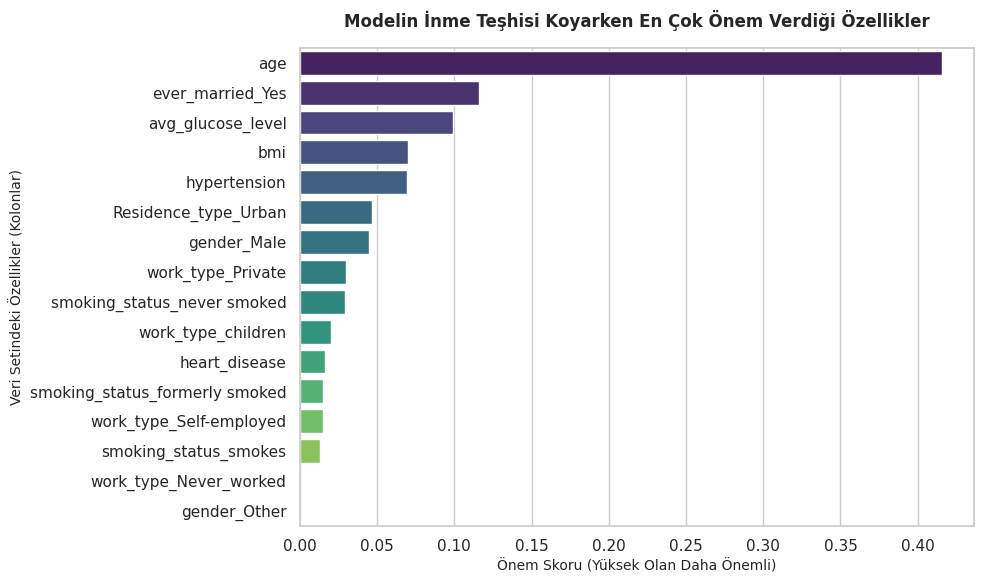

In [60]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# BÖLÜM 1: BİZE EN İYİ SONUCU VEREN STANDART SMOTE MODELİNİ YENİDEN KURMA

final_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
final_model.fit(X_train_resampled, y_train_resampled)

y_pred_final = final_model.predict(X_test_scaled)

# BÖLÜM 2: FİNAL BAŞARI RAPORU VE GÖRSEL CONFUSION MATRIX

print("FİNAL MODEL BAŞARI RAPORU")
print(classification_report(y_test, y_pred_final, zero_division=0))

# Hata Matrisini görselleştirme
cm_final = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['İnme Yok (0)', 'İnme Var (1)'],
            yticklabels=['İnme Yok (0)', 'İnme Var (1)'])
plt.title('Final Modelin Hata Matrisi (En Başarılı Model)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Modelin Yaptığı Tahminler', fontsize=10)
plt.ylabel('Gerçek Durum (Doğru Cevaplar)', fontsize=10)
plt.tight_layout()
plt.show()

# BÖLÜM 3: ÖZELLİK ÖNEM DERECELERİ

importances = final_model.feature_importances_
indices = np.argsort(importances)[::-1]

feature_names = X.columns
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis', hue=feature_names[indices], legend=False)
plt.title('Modelin İnme Teşhisi Koyarken En Çok Önem Verdiği Özellikler', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Önem Skoru (Yüksek Olan Daha Önemli)', fontsize=10)
plt.ylabel('Veri Setindeki Özellikler (Kolonlar)', fontsize=10)
plt.tight_layout()
plt.show()